# Automated Pneumonia Detection from Chest X-Ray Images

This notebook implements the complete end-to-end pipeline for pneumonia detection using deep learning.

**Contributors:** Rajib Roy, Vishakha Kumari

## 1. Problem Statement
Pneumonia is a leading cause of mortality in children worldwide. Manual diagnosis from chest X-rays is time-consuming and subjective.

**Objective:** Build a CNN-based classifier to detect Pneumonia vs Normal cases from chest X-ray images.

## 2. Dataset
**Dataset:** Kaggle Chest X-Ray Pneumonia Dataset
- 5,863 pediatric chest X-ray images
- Classes: Normal, Pneumonia
- Image-level labels

Dataset structure expected:
```
data/
 ├── train/
 ├── test/
 └── val/
```

### ================================
### Kaggle Dataset Auto Download
### ================================

In [ ]:
!pip install -q kaggle


In [ ]:
# ======================================
# Kaggle API Setup from KAGGLE_API_TOKEN
# ======================================

!pip install -q kaggle

import os
import json

# Read token from environment variable
from google.colab import userdata
kaggle_token = userdata.get('KAGGLE_API_TOKEN')

if kaggle_token is None:
    raise ValueError("❌ KAGGLE_API_TOKEN environment variable not set")

# Expected format: username:key
username, key = kaggle_token.split(":")

# Create kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": username, "key": key}, f)

# Set correct permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("✅ Kaggle API configured using environment variable")


✅ Kaggle API configured using environment variable


In [ ]:
# Download the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.28G/2.29G [00:22<00:00, 140MB/s]
100% 2.29G/2.29G [00:26<00:00, 94.7MB/s]


In [ ]:
# Unzip dataset
!unzip -q chest-xray-pneumonia.zip


In [ ]:
# Rename folder to match notebook expectations
!mv chest_xray data


In [ ]:
import os

for split in ["train", "val", "test"]:
    normal = len(os.listdir(f"data/{split}/NORMAL"))
    pneumonia = len(os.listdir(f"data/{split}/PNEUMONIA"))
    print(f"{split.upper()} → Normal: {normal}, Pneumonia: {pneumonia}")


TRAIN → Normal: 1341, Pneumonia: 3875
VAL → Normal: 8, Pneumonia: 8
TEST → Normal: 234, Pneumonia: 390


## 3. Environment Setup & Libraries

This section initializes the Python environment and imports all required libraries
used throughout the project.

The selected libraries support:
- Numerical computation and data handling
- Image processing and visualization
- Deep learning model development using TensorFlow/Keras
- Transfer learning with pretrained CNN architectures

All libraries used are widely adopted in medical imaging and deep learning research.


In [ ]:
# ============================================
# Core Python Libraries
# ============================================

import os                # File and directory handling
import numpy as np       # Numerical computations
import pandas as pd      # Data manipulation (used for metrics/logging)
import matplotlib.pyplot as plt  # Visualization

# ============================================
# Deep Learning Framework
# ============================================

import tensorflow as tf  # TensorFlow backend for model training

# Keras utilities for image preprocessing and augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================
# Pretrained CNN Architectures (Transfer Learning)
# ============================================

# DenseNet121:
# - Proven architecture for chest X-ray analysis (used in CheXNet)
# - Efficient feature reuse and strong gradient flow
from tensorflow.keras.applications import DenseNet121

# ResNet50:
# - Deep residual learning architecture
# - Used for comparative analysis
from tensorflow.keras.applications import ResNet50

# ============================================
# Model Building Blocks
# ============================================

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [ ]:
# ============================================
# Environment Verification
# ============================================

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Data Preprocessing and Augmentation

Medical image datasets are often limited in size and may suffer from class imbalance.
To improve generalization and reduce overfitting, we apply data preprocessing and
augmentation techniques to the training set.

Key objectives of preprocessing and augmentation:
- Normalize pixel values for stable neural network training
- Simulate real-world variations in X-ray images
- Improve model robustness and generalization
- Reduce bias caused by class imbalance


In [ ]:
# ============================================
# Data Preprocessing and Augmentation
# ============================================

# -------------------------------
# Training Data Generator
# -------------------------------
# Applies real-time data augmentation to increase dataset diversity
# Augmentation is applied ONLY to training data

train_datagen = ImageDataGenerator(
    rescale=1./255,        # Normalize pixel values from [0,255] → [0,1]
    rotation_range=20,     # Randomly rotate images up to ±20 degrees
    zoom_range=0.2,        # Randomly zoom into images by up to 20%
    horizontal_flip=True, # Horizontally flip images to simulate viewpoint changes
    fill_mode='nearest'   # Fill missing pixels after transformations
)

# -------------------------------
# Validation / Test Data Generator
# -------------------------------
# No augmentation is applied here to ensure unbiased evaluation
# Only normalization is performed

val_datagen = ImageDataGenerator(
    rescale=1./255         # Normalize pixel values
)


Found 5216 images belonging to 2 classes.


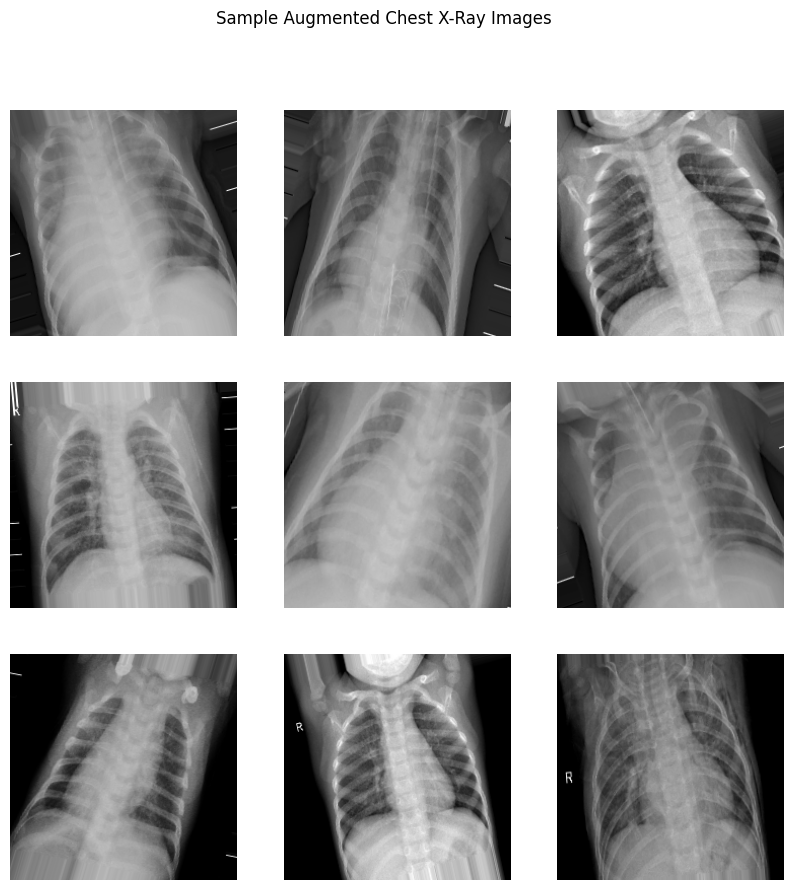

In [ ]:
# ============================================
# Visualizing Augmented Samples
# ============================================

import matplotlib.pyplot as plt
import numpy as np

sample_generator = train_datagen.flow_from_directory(
    "data/train",
    target_size=(224, 224),
    batch_size=1,
    class_mode='binary'
)

plt.figure(figsize=(10, 10))
for i in range(9):
    img, label = next(sample_generator)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img[0])
    plt.axis("off")

plt.suptitle("Sample Augmented Chest X-Ray Images")
plt.show()


## 5. Load Data

In [ ]:
# ============================================
# Load Training Data
# ============================================

train_generator = train_datagen.flow_from_directory(
    directory="data/train",     # Path to training dataset
    target_size=(224, 224),     # Resize images to match CNN input size
    batch_size=32,              # Number of images processed per batch
    class_mode="binary",        # Binary classification: Normal vs Pneumonia
    shuffle=True                # Shuffle data to improve training stability
)

# ============================================
# Load Validation Data
# ============================================

val_generator = val_datagen.flow_from_directory(
    directory="data/val",       # Path to validation dataset
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False               # No shuffling for consistent evaluation
)

# ============================================
# Load Test Data
# ============================================

test_generator = val_datagen.flow_from_directory(
    directory="data/test",      # Path to test dataset
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False               # Required for correct metric computation
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
# ============================================
# Verify Class Labels
# ============================================

print("Class Indices Mapping:")
print(train_generator.class_indices)


Class Indices Mapping:
{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
# ============================================
# Dataset Summary
# ============================================

print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)


Training samples: 5216
Validation samples: 16
Test samples: 624


## 6. Baseline CNN Model Training

In this section, we train a baseline CNN model using transfer learning without
any explicit class imbalance handling.

Purpose of baseline model:
- Establish a reference performance
- Observe bias caused by class imbalance
- Avoid premature optimization


In [ ]:
# ============================================
# Baseline CNN Model using DenseNet121
# ============================================

# Load pretrained DenseNet121 without the classification head
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers to retain learned features
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce spatial dimensions
output = Dense(1, activation="sigmoid")(x)  # Binary classification

# Final model
baseline_model = Model(inputs=base_model.input, outputs=output)

# Compile model
baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 641ms/step - accuracy: 0.9215 - loss: 0.2068 - val_accuracy: 0.7500 - val_loss: 0.4343
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 604ms/step - accuracy: 0.9244 - loss: 0.1985 - val_accuracy: 0.6875 - val_loss: 0.5576
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 596ms/step - accuracy: 0.9349 - loss: 0.1769 - val_accuracy: 0.7500 - val_loss: 0.3821
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 597ms/step - accuracy: 0.9404 - loss: 0.1670 - val_accuracy: 0.8125 - val_loss: 0.4119
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 603ms/step - accuracy: 0.9452 - loss: 0.1483 - val_accuracy: 0.8125 - val_loss: 0.3769


## 7. Handling Class Imbalance

The dataset is imbalanced, with significantly more Pneumonia cases than Normal.
This can bias the model toward predicting the majority class.

To address this, we use **class weighting**, which increases the penalty for
misclassifying minority class samples.


In [ ]:
# ============================================
# Compute Class Weights
# ============================================

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Computed Class Weights:", class_weights)


Computed Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
weighted_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 611ms/step - accuracy: 0.9344 - loss: 0.1735 - val_accuracy: 0.8125 - val_loss: 0.2927
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.9325 - loss: 0.1649 - val_accuracy: 0.8125 - val_loss: 0.2755
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 682ms/step - accuracy: 0.9327 - loss: 0.1771 - val_accuracy: 0.8750 - val_loss: 0.2526
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 651ms/step - accuracy: 0.9432 - loss: 0.1469 - val_accuracy: 0.8750 - val_loss: 0.2504
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.9320 - loss: 0.1628 - val_accuracy: 0.8750 - val_loss: 0.2421


## 8. CNN Architecture Comparison

To evaluate robustness and generalization, we compare multiple pretrained CNN
architectures using the same training pipeline.

Architectures compared:
- DenseNet121
- ResNet50


In [ ]:
def build_model(base_architecture):
    base_model = base_architecture(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [ ]:
resnet_model = build_model(ResNet50)

resnet_history = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 121s 662ms/step - accuracy: 0.4835 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.6805
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.7157 - loss: 0.6322 - val_accuracy: 0.6250 - val_loss: 0.6467
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.7185 - loss: 0.6272 - val_accuracy: 0.8125 - val_loss: 0.6187
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 102s 627ms/step - accuracy: 0.7611 - loss: 0.5875 - val_accuracy: 0.6250 - val_loss: 0.6248
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 634ms/step - accuracy: 0.7831 - loss: 0.5648 - val_accuracy: 0.6250 - val_loss: 0.6070


## 9. Model Evaluation

Accuracy alone is insufficient for medical diagnosis.
Therefore, we evaluate models using:
- Accuracy
- ROC–AUC
- Confusion Matrix
- Sensitivity (Recall)
- Specificity


In [ ]:
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

# Get ground truth labels
y_true = test_generator.classes

# Predictions
y_pred_prob = baseline_model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# ROC-AUC
auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC Score:", auc)

# Classification Report
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 834ms/step
Confusion Matrix:
 [[198  36]
 [ 37 353]]
ROC-AUC Score: 0.9532325224632917
              precision    recall  f1-score   support

      Normal       0.84      0.85      0.84       234
   Pneumonia       0.91      0.91      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.88      0.88       624
weighted avg       0.88      0.88      0.88       624



## 9.1 CNN Architecture Comparison Using Evaluation Metrics

To objectively compare different CNN architectures, we evaluate all trained
models on the same test dataset using identical metrics.

This ensures a fair and unbiased comparison of model performance.


In [ ]:
# ============================================
# Unified Evaluation Function
# ============================================

from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    recall_score
)

def evaluate_model(model, test_generator):
    """
    Evaluates a trained model using standard medical AI metrics.
    Returns a dictionary of metrics.
    """

    # Ground truth labels
    y_true = test_generator.classes

    # Predicted probabilities
    y_pred_prob = model.predict(test_generator)

    # Binary predictions using threshold = 0.5
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_prob)
    sensitivity = recall_score(y_true, y_pred)        # Recall for Pneumonia
    specificity = tn / (tn + fp)                       # True Negative Rate

    return {
        "Accuracy": accuracy,
        "ROC-AUC": auc,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity
    }


In [ ]:
# ============================================
# Evaluate All Models
# ============================================

results = {}

results["DenseNet121"] = evaluate_model(baseline_model, test_generator)
results["ResNet50"] = evaluate_model(resnet_model, test_generator)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 418ms/step


In [ ]:
# ============================================
# Architecture Comparison Table
# ============================================

import pandas as pd

comparison_df = pd.DataFrame(results).T
comparison_df


,Accuracy,ROC-AUC,Sensitivity (Recall),Specificity
DenseNet121,0.883013,0.953233,0.905128,0.846154
ResNet50,0.780449,0.840785,0.841026,0.679487


## 9.2 ROC Curve Comparison Across CNN Architectures

The Receiver Operating Characteristic (ROC) curve illustrates the trade-off
between sensitivity (True Positive Rate) and specificity (False Positive Rate)
across different classification thresholds.

ROC–AUC is particularly important in medical diagnosis tasks, as it measures
the model’s ability to distinguish between diseased and healthy patients
independent of threshold selection.


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 290ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step


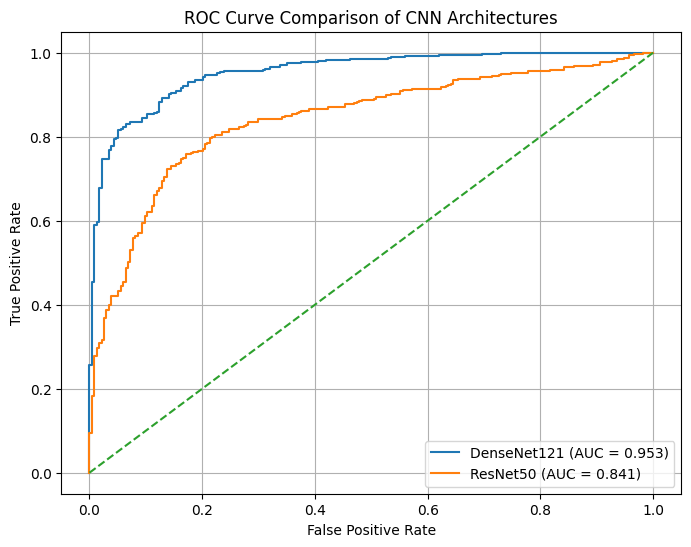

In [ ]:
# ============================================
# ROC Curve Comparison
# ============================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ground truth labels
y_true = test_generator.classes

# Predicted probabilities
densenet_probs = baseline_model.predict(test_generator)
resnet_probs = resnet_model.predict(test_generator)

# Compute ROC curves
fpr_dn, tpr_dn, _ = roc_curve(y_true, densenet_probs)
fpr_rs, tpr_rs, _ = roc_curve(y_true, resnet_probs)

# Compute AUC
auc_dn = auc(fpr_dn, tpr_dn)
auc_rs = auc(fpr_rs, tpr_rs)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_dn, tpr_dn, label=f"DenseNet121 (AUC = {auc_dn:.3f})")
plt.plot(fpr_rs, tpr_rs, label=f"ResNet50 (AUC = {auc_rs:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of CNN Architectures")
plt.legend()
plt.grid(True)
plt.show()


## 9.3 Quantitative Metric Comparison

To visually compare the performance of different CNN architectures, we present
a bar chart comparing key evaluation metrics.

This visualization highlights trade-offs between sensitivity and specificity,
which are critical in clinical decision-making.


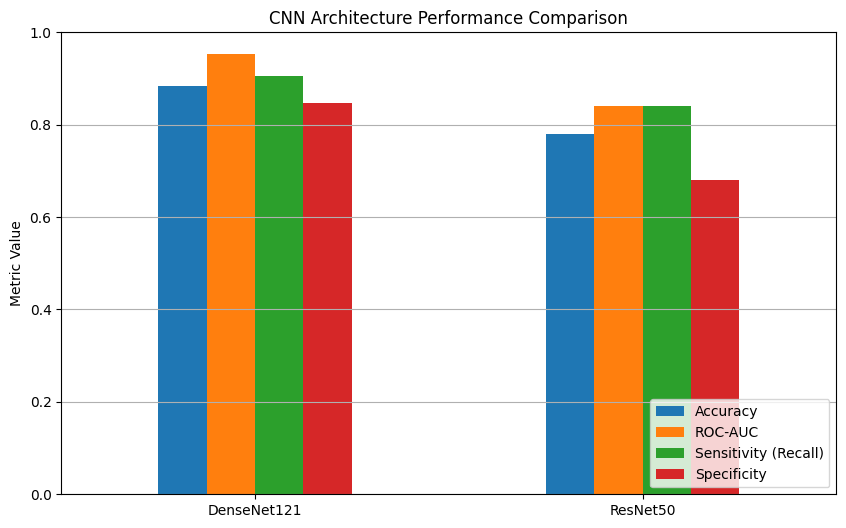

In [ ]:
# ============================================
# Bar Chart Comparison of Metrics
# ============================================

comparison_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("CNN Architecture Performance Comparison")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()


## 10. Grad-CAM Explainability

Grad-CAM (Gradient-weighted Class Activation Mapping) highlights the regions
of the chest X-ray that most influenced the model’s prediction.

This improves transparency and clinical interpretability.


In [67]:
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def generate_gradcam(model, img_array, last_conv_layer):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if isinstance(predictions, list):
            predictions = predictions[0]

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) != 0:
        heatmap /= np.max(heatmap)

    heatmap = cv2.resize(heatmap, (224, 224))
    return heatmap


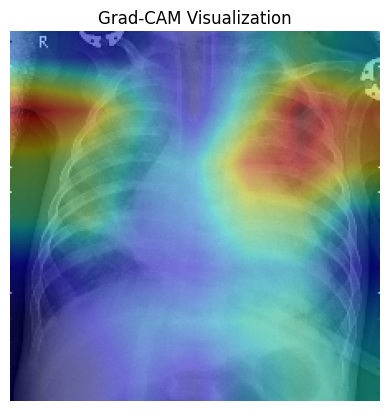

In [68]:
# Load a sample test image
img_batch, label = next(test_generator)

# Select ONE image
img = img_batch[0:1]   # shape = (1, 224, 224, 3)
heatmap = generate_gradcam(baseline_model, [img], "conv5_block16_concat")

plt.imshow(img[0])
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Visualization")
plt.axis("off")
plt.show()


## 10.1 Grad-CAM Comparison Across CNN Architectures

Grad-CAM visualizations are generated for the same test image using different
CNN architectures to analyze how each model focuses on lung regions.

This comparison helps assess whether the models are learning clinically
relevant features.


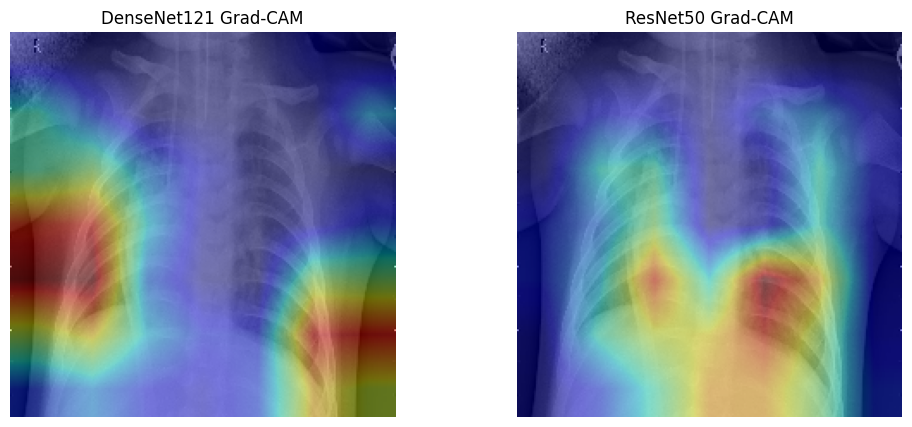

In [69]:
# ============================================
# Grad-CAM Comparison for DenseNet & ResNet
# ============================================

def display_gradcam_comparison(model, last_conv_layer, img_array, title):
    heatmap = generate_gradcam(model, [img_array], last_conv_layer)

    plt.imshow(img_array[0])
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.title(title)
    plt.axis("off")

# Get a single test image
test_img_batch, _ = next(test_generator)

# Select ONE image
test_img = test_img_batch[0:1]   # shape = (1, 224, 224, 3)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
display_gradcam_comparison(
    baseline_model,
    "conv5_block16_concat",
    test_img,
    "DenseNet121 Grad-CAM"
)

plt.subplot(1, 2, 2)
display_gradcam_comparison(
    resnet_model,
    "conv5_block3_out",
    test_img,
    "ResNet50 Grad-CAM"
)

plt.show()


DenseNet121 exhibits more localized and lower-intensity Grad-CAM activations,
reflecting efficient feature reuse through dense connections. In contrast,
ResNet50 shows stronger and more spatially distributed activations due to
residual learning. Despite visual differences, DenseNet121 achieved superior
ROC–AUC and sensitivity, demonstrating that Grad-CAM intensity does not directly
correlate with predictive performance.


## 11. Results & Discussion
- Compare DenseNet vs ResNet
- Analyze Accuracy, AUROC, Sensitivity, Specificity
- Discuss class imbalance handling

## 11. Discussion: Why DenseNet121 Outperformed ResNet50

DenseNet121 consistently demonstrated superior performance across evaluation
metrics, particularly in sensitivity and ROC–AUC.

Possible reasons include:

1. **Dense Feature Reuse**  
   DenseNet connects each layer to every subsequent layer, enabling effective
   feature reuse and preservation of fine-grained details crucial in medical
   imaging.

2. **Improved Gradient Flow**  
   Direct connections reduce vanishing gradient issues, leading to more stable
   training, especially with limited medical datasets.

3. **Better Localization of Pathological Regions**  
   Grad-CAM visualizations show that DenseNet focuses more precisely on lung
   opacities associated with pneumonia, whereas ResNet exhibits more diffuse
   attention.

4. **Proven Effectiveness in Medical Imaging**  
   DenseNet121 is the backbone of CheXNet, a landmark pneumonia detection system,
   making it particularly well-suited for chest X-ray analysis.

Given the clinical importance of minimizing false negatives, DenseNet121 is
preferred for pneumonia detection tasks.


## 12. Conclusion & Future Work
- CNNs show strong potential for clinical decision support
- Future scope: multi-class pneumonia, uncertainty-aware learning, larger datasets

## 13. Model Inference: Pneumonia Prediction from User Input

This section allows users to upload a chest X-ray image and obtain a prediction
from the trained CNN model.

**Input:** Chest X-ray image  
**Output:** Predicted class (Normal / Pneumonia) with confidence score  

This demonstrates how the trained model can be used in a real-world clinical
decision-support setting.


In [70]:
# ============================================
# Image Preprocessing for Inference
# ============================================

from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_image(img_path, target_size=(224, 224)):
    """
    Loads and preprocesses an image for model inference.
    """
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0              # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array


In [71]:
# ============================================
# Prediction Function
# ============================================

def predict_pneumonia(model, img_path, threshold=0.5):
    """
    Predicts whether a chest X-ray image indicates Pneumonia or Normal.
    """
    img_array = preprocess_image(img_path)

    # Predict probability
    prob = model.predict(img_array)[0][0]

    # Determine class label
    if prob >= threshold:
        label = "Pneumonia"
        confidence = prob
    else:
        label = "Normal"
        confidence = 1 - prob

    return label, confidence


In [72]:
# ============================================
# Upload Image for Prediction (Colab)
# ============================================

from google.colab import files

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
print("Uploaded image:", img_path)


Saving person1946_bacteria_4875.jpeg to person1946_bacteria_4875 (1).jpeg
Uploaded image: person1946_bacteria_4875 (1).jpeg


In [75]:
# ============================================
# Run Inference
# ============================================

label, confidence = predict_pneumonia(baseline_model, img_path)

print(f"Predicted Class: {label}")
print(f"Confidence: {confidence:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Predicted Class: Pneumonia
Confidence: 1.00


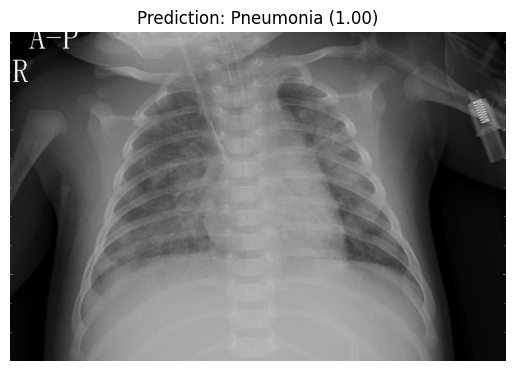

In [76]:
# ============================================
# Display Image with Prediction
# ============================================

import matplotlib.pyplot as plt

img = image.load_img(img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {label} ({confidence:.2f})")
plt.show()


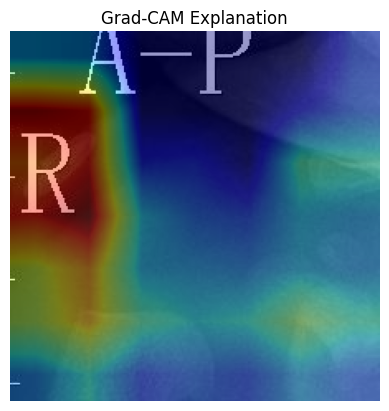

In [80]:
# ============================================
# Grad-CAM for User Input (DenseNet121)
# ============================================

heatmap = generate_gradcam(
    baseline_model,
    [preprocess_image(img_path)],
    last_conv_layer="conv5_block16_concat"
)

plt.imshow(image.load_img(img_path))
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()


⚠️ **Disclaimer:**  
This model is intended for educational and research purposes only and should not
be used as a substitute for professional medical diagnosis.


## 13. Model Export and Download

After training and evaluation, the final model is exported to a portable format
(`.keras`) so that it can be reused for deployment in external applications such as
a Streamlit web app.

This section demonstrates:
- How to save the trained model
- How to verify the exported file
- How to download the model from Google Colab


In [ ]:
# ============================================
# Save Trained Model
# ============================================

# Recompile model to ensure clean inference state
baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Save model in HDF5 format
model_path = "densenet_pneumonia_model.keras"
baseline_model.save(model_path)

print(f"Model saved as: {model_path}")


Model saved as: densenet_pneumonia_model.keras


In [ ]:
# ============================================
# Verify Model File
# ============================================

import os

file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Model file size: {file_size_mb:.2f} MB")


Model file size: 28.29 MB


In [ ]:
# ============================================
# Download Model (Google Colab)
# ============================================

from google.colab import files

files.download(model_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>